# **Feature Extraction** for NeoScreen
## Extracting audio features from all three datasets: **ICBHI 2017**, **HLS-CMDS**, **SPRSound**

In [11]:
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
sys.path.append('..')

from src.feature_extraction.audio_features import AudioFeatureExtractor

print("Imports successful")

Imports successful


## 1. Initialize Feature Extractor

In [12]:
extractor = AudioFeatureExtractor(sr=4000, n_mfcc=13)
print("Feature extractor initialized")

AudioFeatureExtractor initialized with sr=4000, n_mfcc=13
Feature extractor initialized


## 2. ICBHI 2017 Feature Extraction

In [13]:
# Path to ICBHI dataset
icbhi_path = Path("../sound_data/icbhi")

# Find all audio files
if icbhi_path.exists():
    icbhi_files = list(icbhi_path.glob("*.wav"))
    print(f"Found {len(icbhi_files)} ICBHI files")
    
else:
    print("ICBHI folder not found")
    icbhi_files = []
    
# Extract discovered features
if len(icbhi_files) > 0:
    print("\n" + "="*50)
    print("EXTRACTING ICBHI FEATURES")
    print("="*50)
    
    # Extract from all files
    df_icbhi = extractor.extract_batch(
        icbhi_files, 
        output_csv="../sound_data/features/icbhi_features.csv"
    )
    
    print(f"Complete! {len(df_icbhi)} files processed")
    
    # Add dataset label
    df_icbhi['dataset'] = 'ICBHI'
else:
    print("No ICBHI files found")
    df_icbhi = pd.DataFrame()

Found 920 ICBHI files

EXTRACTING ICBHI FEATURES

 Processing 920 files...
   Progress: 0/920 (Success: 0, Failed: 0)
   Progress: 10/920 (Success: 10, Failed: 0)
   Progress: 20/920 (Success: 20, Failed: 0)
   Progress: 30/920 (Success: 30, Failed: 0)
   Progress: 40/920 (Success: 40, Failed: 0)
   Progress: 50/920 (Success: 50, Failed: 0)
   Progress: 60/920 (Success: 60, Failed: 0)
   Progress: 70/920 (Success: 70, Failed: 0)
   Progress: 80/920 (Success: 80, Failed: 0)
   Progress: 90/920 (Success: 90, Failed: 0)
   Progress: 100/920 (Success: 100, Failed: 0)
   Progress: 110/920 (Success: 110, Failed: 0)
   Progress: 120/920 (Success: 120, Failed: 0)
   Progress: 130/920 (Success: 130, Failed: 0)
   Progress: 140/920 (Success: 140, Failed: 0)
   Progress: 150/920 (Success: 150, Failed: 0)
   Progress: 160/920 (Success: 160, Failed: 0)
   Progress: 170/920 (Success: 170, Failed: 0)
   Progress: 180/920 (Success: 180, Failed: 0)
   Progress: 190/920 (Success: 190, Failed: 0)
   Prog

 ## 3. HLS-CMDS Feature Extraction (Lung Sounds only)

In [14]:
# Path to HLS-CMDS
hls_path = Path("../sound_data/hls-cmds")

# Find all lung sound files (LS)
ls_files = []
ls_audio_path = hls_path / "LS" / "LS_audio"

if ls_audio_path.exists():
    ls_files = list(ls_audio_path.glob("*.wav"))
    print(f"Found {len(ls_files)} lung sound files in HLS-CMDS")
else:
    print("LS_audio folder not found")

# HLS-CMDS - ALL lung sound files
if len(ls_files) > 0:
    print("\n" + "="*50)
    print("EXTRACTING HLS-CMDS FEATURES")
    print("="*50)
    
    # Extract from all files 
    df_hls = extractor.extract_batch(
        ls_files, 
        output_csv="../sound_data/features/hls_features.csv"
    )
    print(f"Complete! {len(df_hls)} files processed")
 
 # Add dataset label
    df_hls['dataset'] = 'HLS-CMDS'    
else:
    print("No HLS-CMDS lung sound files found")
    
    df_hls = pd.DataFrame()

Found 50 lung sound files in HLS-CMDS

EXTRACTING HLS-CMDS FEATURES

 Processing 50 files...
   Progress: 0/50 (Success: 0, Failed: 0)
   Progress: 10/50 (Success: 10, Failed: 0)
   Progress: 20/50 (Success: 20, Failed: 0)
   Progress: 30/50 (Success: 30, Failed: 0)
   Progress: 40/50 (Success: 40, Failed: 0)

 Completed: 50 successful, 0 failed
Saved features to ../sound_data/features/hls_features.csv
Complete! 50 files processed


## 4. SPRSound Feature Extraction

In [15]:
# Function to find all WAV files in SPRSound
def find_sprsound_wavs(base_path):
    # Recursively find all .wav files in SPRSound folder
    wav_files = []
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith('.wav') or file.endswith('.WAV'):
                wav_files.append(Path(root) / file)
    return wav_files

# Path to SPRSound
sprsound_path = Path("../sound_data/sprsound")

if sprsound_path.exists():
    # Find all WAV files
    sprsound_files = find_sprsound_wavs(sprsound_path)
    print(f"Found {len(sprsound_files)} SPRSound files")
    
else:
    print("SPRSound folder not found")
    
if len(sprsound_files) > 0:
    print("\n Files by folder:")
    folders = {}
    for f in sprsound_files:
        parent = f.parent.name
        folders[parent] = folders.get(parent, 0) + 1
    for folder, count in sorted(folders.items()):
        print(f"   - {folder}: {count} files")
    
    print("\n" + "="*50)
    print("EXTRACTING SPRSOUND FEATURES")
    print("="*50)
    
    df_sprsound = extractor.extract_batch(
        sprsound_files,  # ALL files
        output_csv="../sound_data/features/sprsound_features.csv"
    )
    print(f"Complete! {len(df_sprsound)} files processed")
else:
    print("No .wav files found in SPRSound folder")

Found 6567 SPRSound files

 Files by folder:
   - test2022_wav: 734 files
   - test2023_wav: 871 files
   - test2024_wav: 1704 files
   - test2025_wav: 1309 files
   - train2022_wav: 1949 files

EXTRACTING SPRSOUND FEATURES

 Processing 6567 files...
   Progress: 0/6567 (Success: 0, Failed: 0)
   Progress: 10/6567 (Success: 10, Failed: 0)
   Progress: 20/6567 (Success: 20, Failed: 0)
   Progress: 30/6567 (Success: 30, Failed: 0)
   Progress: 40/6567 (Success: 40, Failed: 0)
   Progress: 50/6567 (Success: 50, Failed: 0)
   Progress: 60/6567 (Success: 60, Failed: 0)
   Progress: 70/6567 (Success: 70, Failed: 0)
   Progress: 80/6567 (Success: 80, Failed: 0)
   Progress: 90/6567 (Success: 90, Failed: 0)
   Progress: 100/6567 (Success: 100, Failed: 0)
   Progress: 110/6567 (Success: 110, Failed: 0)
   Progress: 120/6567 (Success: 120, Failed: 0)
   Progress: 130/6567 (Success: 130, Failed: 0)
   Progress: 140/6567 (Success: 140, Failed: 0)
   Progress: 150/6567 (Success: 150, Failed: 0)
   

## 5. Combine All Features

In [16]:
print("\n" + "="*50)
print("COMBINING ALL FEATURES")
print("="*50)

# Collect all dataframes that have data
all_dfs = []
dataset_names = []

# Check ICBHI (from previous cells)
if 'df_icbhi' in locals() and len(df_icbhi) > 0:
    df_icbhi['dataset'] = 'ICBHI'
    all_dfs.append(df_icbhi)
    dataset_names.append('ICBHI')

# Check HLS
if 'df_hls' in locals() and len(df_hls) > 0:
    all_dfs.append(df_hls)
    dataset_names.append('HLS-CMDS')

# Check SPRSound
if 'df_sprsound' in locals() and len(df_sprsound) > 0:
    all_dfs.append(df_sprsound)
    dataset_names.append('SPRSound')

if all_dfs:
    # Combine all features
    df_all = pd.concat(all_dfs, ignore_index=True)
    
    print(f"\n Combined features shape: {df_all.shape}")
    print(f"Total files processed: {len(df_all)}")
    print(f"\n Files by dataset:")
    print(df_all['dataset'].value_counts())
    
    # Save combined features
    df_all.to_csv("../sound_data/features/all_features.csv", index=False)
    print(f"\n Saved combined features to: ../sound_data/features/all_features.csv")
    
    # Show basic statistics
    print("\n Feature statistics by dataset:")
    key_cols = ['mfcc_1_mean', 'zcr_mean', 'rms_mean', 'harmonic_ratio', 'duration']
    available_cols = [c for c in key_cols if c in df_all.columns]
    
    if available_cols:
        print(df_all.groupby('dataset')[available_cols].mean().round(4))
else:
    print("No features extracted from any dataset")


COMBINING ALL FEATURES

 Combined features shape: (7537, 36)
Total files processed: 7537

 Files by dataset:
dataset
ICBHI       920
HLS-CMDS     50
Name: count, dtype: int64

 Saved combined features to: ../sound_data/features/all_features.csv

 Feature statistics by dataset:
          mfcc_1_mean  zcr_mean  rms_mean  harmonic_ratio  duration
dataset                                                            
HLS-CMDS  -615.910522    0.0952    0.0029          0.5184   15.0000
ICBHI     -270.669189    0.0271    0.1703          0.6171   21.4924


## 6. Visualize Extracted Features

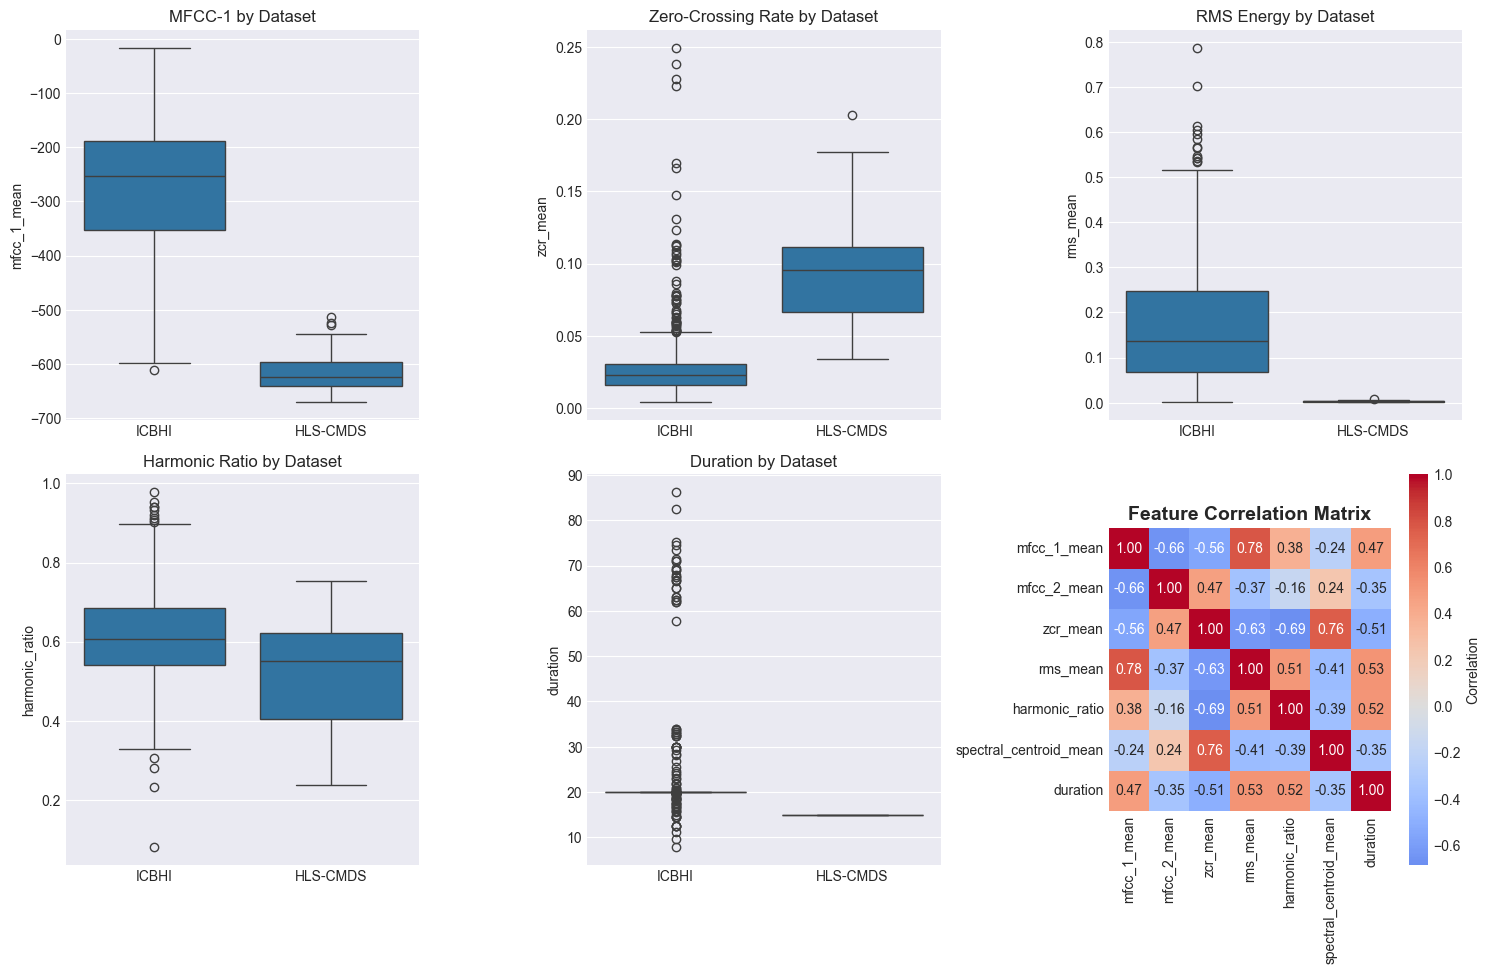


 Saved feature comparison plot to: reports/figures/feature_comparison.png


In [17]:
if 'df_all' in locals() and len(df_all) > 0:
    # Set style
    plt.style.use('seaborn-v0_8-darkgrid')
    
    # figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    # Plot 1: MFCC1 by dataset
    if 'mfcc_1_mean' in df_all.columns:
        sns.boxplot(x='dataset', y='mfcc_1_mean', data=df_all, ax=axes[0])
        axes[0].set_title('MFCC-1 by Dataset')
        axes[0].set_xlabel('')
    
    # Plot 2: Zero-crossing rate
    if 'zcr_mean' in df_all.columns:
        sns.boxplot(x='dataset', y='zcr_mean', data=df_all, ax=axes[1])
        axes[1].set_title('Zero-Crossing Rate by Dataset')
        axes[1].set_xlabel('')
    
    # Plot 3: RMS Energy
    if 'rms_mean' in df_all.columns:
        sns.boxplot(x='dataset', y='rms_mean', data=df_all, ax=axes[2])
        axes[2].set_title('RMS Energy by Dataset')
        axes[2].set_xlabel('')
    
    # Plot 4: Harmonic Ratio
    if 'harmonic_ratio' in df_all.columns:
        sns.boxplot(x='dataset', y='harmonic_ratio', data=df_all, ax=axes[3])
        axes[3].set_title('Harmonic Ratio by Dataset')
        axes[3].set_xlabel('')
    
    # Plot 5: Duration
    if 'duration' in df_all.columns:
        sns.boxplot(x='dataset', y='duration', data=df_all, ax=axes[4])
        axes[4].set_title('Duration by Dataset')
        axes[4].set_xlabel('')
    
   # Plot 6: Correlation Heatmap of key features (considered numerical columns only)
    feature_cols = ['mfcc_1_mean', 'mfcc_2_mean', 'zcr_mean', 'rms_mean', 
                    'harmonic_ratio', 'spectral_centroid_mean', 'duration']
    available_cols = [c for c in feature_cols if c in df_all.columns]
    
    if len(available_cols) > 1:
        corr_matrix = df_all[available_cols].corr()
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                    center=0, square=True, ax=axes[5], 
                    cbar_kws={'label': 'Correlation'})
        axes[5].set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
    else:
        axes[5].text(0.5, 0.5, 'Insufficient features\nfor correlation', 
                    ha='center', va='center', fontsize=12)
        axes[5].set_title('Feature Correlation', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/feature_comparison_6plots.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n Saved feature comparison plot to: reports/figures/feature_comparison.png")

 ## 7. Summary of Extracted Features

In [18]:
print("\n" + "="*60)
print("FEATURE EXTRACTION SUMMARY")
print("="*60)

if 'df_all' in locals() and len(df_all) > 0:
    print(f"\n Total audio files processed: {len(df_all)}")
    print(f" Total features per file: {len(df_all.columns) - 3} (excluding metadata)")
    print(f"\n Datasets processed:")
    for dataset, count in df_all['dataset'].value_counts().items():
        print(f"   - {dataset}: {count} files")
    
    print(f"\n Features extracted:")
    feature_cols = [c for c in df_all.columns if c not in ['filename', 'file_path', 'dataset']]
    print(f"1. MFCCs: 13 coefficients (mean + std)")
    print(f"2. Temporal: zcr_mean, rms_mean, duration")
    print(f"3. Spectral: harmonic_ratio, spectral_centroid_mean")
    print(f"\n All features saved to: sound_data/features/all_features.csv")
else:
    print("No features were extracted")

print("\n" + "="*60)


FEATURE EXTRACTION SUMMARY

 Total audio files processed: 7537
 Total features per file: 33 (excluding metadata)

 Datasets processed:
   - ICBHI: 920 files
   - HLS-CMDS: 50 files

 Features extracted:
1. MFCCs: 13 coefficients (mean + std)
2. Temporal: zcr_mean, rms_mean, duration
3. Spectral: harmonic_ratio, spectral_centroid_mean

 All features saved to: sound_data/features/all_features.csv



In [19]:
df = pd.read_csv("../sound_data/features/all_features.csv")
print(f"Total files: {len(df)}")
print(df['dataset'].value_counts())

Total files: 7537
dataset
ICBHI       920
HLS-CMDS     50
Name: count, dtype: int64
